In [8]:
# modules and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
print("Imported")

Imported


In [9]:
np.random.seed(42)
# 200 temperature readings between 10°C and 130°C
temperature = np.sort(np.random.uniform(10, 130, 200))

# generate efficiency (Peaks at 70°C, drops off on either side, plus some random noise)
# inverted parabola formula: y = a(x - h)^2 + k, because on extreme cold or hot engine breaks
efficiency = -0.015 * (temperature - 70)**2 + 85 + np.random.normal(0, 5, 200)

# Create DataFrame
df = pd.DataFrame({
    'Temperature': temperature,
    'Efficiency': efficiency
})

X = df[['Temperature']]
y = df['Efficiency']

print("data generated successfully!")

data generated successfully!


In [10]:
df.head()

,Temperature,Efficiency
0,10.662654,28.786067
1,10.834256,33.652489
2,11.990539,35.988900
3,12.470139,31.782970
4,13.050295,45.679839


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# sort test data for smooth plotting later
sort_idx = X_test.index.argsort()
X_test_sorted = X_test.loc[X_test.index[sort_idx]]
y_test_sorted = y_test.loc[y_test.index[sort_idx]]

model_lin = LinearRegression()
model_lin.fit(X_train, y_train)
pred_lin = model_lin.predict(X_test_sorted)
mse_lin = mean_squared_error(y_test_sorted, pred_lin)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test_sorted)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
pred_poly = model_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test_sorted, pred_poly)

model_tree = DecisionTreeRegressor(max_depth=4, random_state=42)
model_tree.fit(X_train, y_train)
pred_tree = model_tree.predict(X_test_sorted)
mse_tree = mean_squared_error(y_test_sorted, pred_tree)

print("--- MSE(Lower is better) ---")
print(f"Linear Regression:     {mse_lin:.2f}")
print(f"Polynomial (Degree 2): {mse_poly:.2f}")
print(f"Decision Tree:         {mse_tree:.2f}")

--- MSE(Lower is better) ---
Linear Regression:     192.38
Polynomial (Degree 2): 27.19
Decision Tree:         39.37


In [15]:
df.to_csv('/home/rohitsolanki/programs/jupyter/data/EngineVSTemp.csv', index=False)
print("EngineVSTemp.csv successfully created with 100 rows!")
display(df.head(15))

EngineVSTemp.csv successfully created with 100 rows!


,Temperature,Efficiency
0,10.662654,28.786067
1,10.834256,33.652489
2,11.990539,35.988900
3,12.470139,31.782970
4,13.050295,45.679839
5,13.771502,39.944505
6,14.126623,32.215968
7,14.426434,41.956449
8,14.893017,34.574898
9,15.427275,44.262688


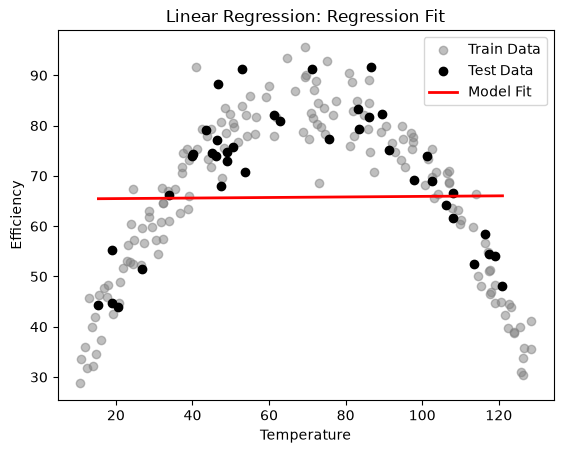

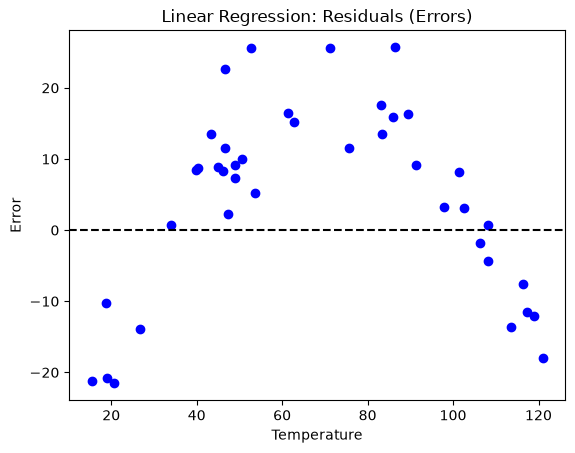

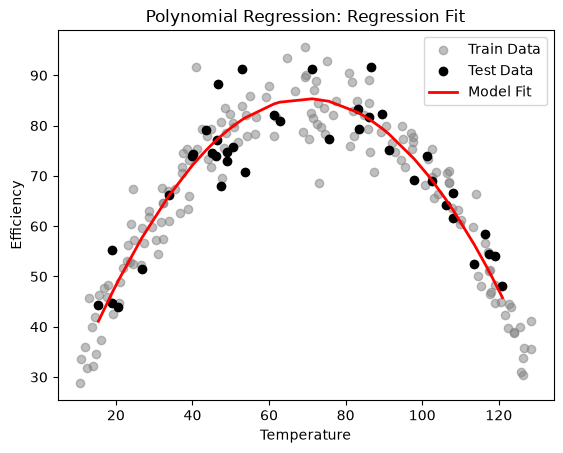

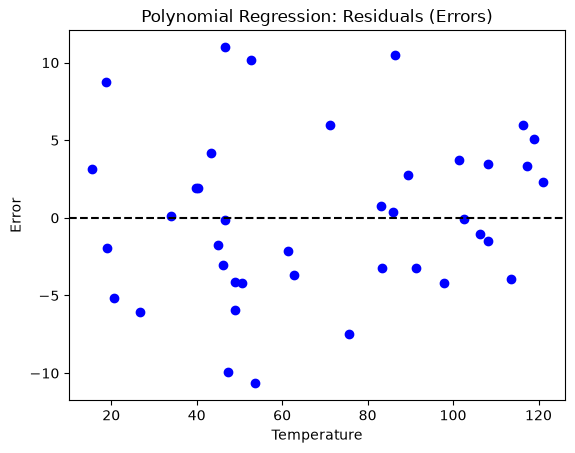

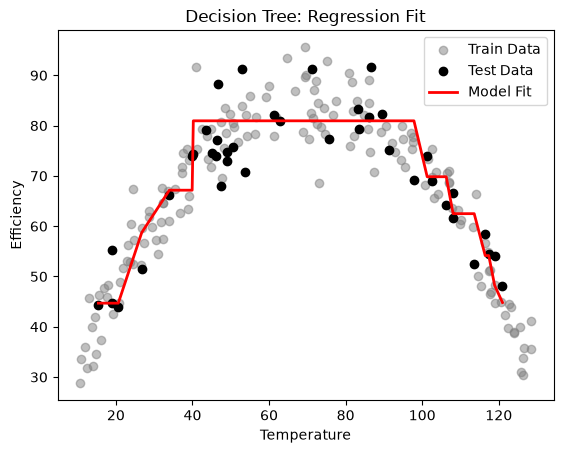

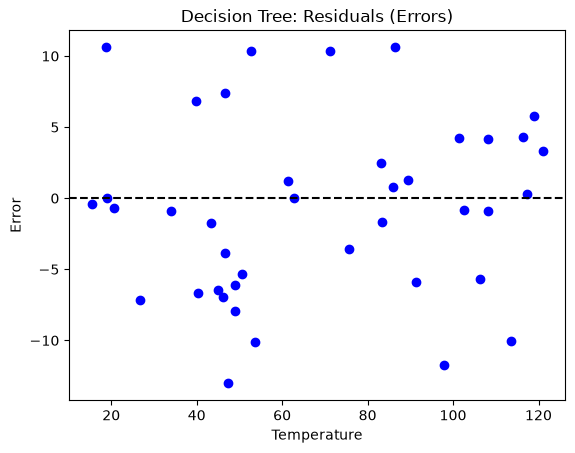

In [17]:
predictions_dict = {
    "Linear Regression": pred_lin,
    "Polynomial Regression": pred_poly,
    "Decision Tree": pred_tree
}

for name, predictions in predictions_dict.items():
    
    plt.scatter(X_train, y_train, color='gray', alpha=0.5, label='Train Data')
    plt.scatter(X_test_sorted, y_test_sorted, color='black', label='Test Data')
    plt.plot(X_test_sorted, predictions, color='red', linewidth=2, label='Model Fit')
    
    plt.title(f"{name}: Regression Fit")
    plt.xlabel("Temperature")
    plt.ylabel("Efficiency")
    plt.legend()
    plt.show() 
    
    residuals = y_test_sorted - predictions
    
    plt.scatter(X_test_sorted, residuals, color='blue')
    plt.axhline(0, color='black', linestyle='--') 
    
    plt.title(f"{name}: Residuals (Errors)")
    plt.xlabel("Temperature")
    plt.ylabel("Error")
    plt.show()

# Simply I can see that polynomial prediction is very well suited and best for this kind of ditributionm and I think Decision tree also performed well but linear model are bad for this

# Discussion

**Why does Linear Regression fail to capture the relationship?**
### Because it's normally useful for linearly seperable data but data seems to be non-linear. It has only one direction of seperation.

**How does feature transformation (Polynomial Regression) improve the model?**
### Polynomial simply maths to provide linear method into able to create parabola and scan the data which is not linear

**Compare interpretability and flexibility of the different approaches.**
### linear and polynomial is easy to interpret and understand and decision tree is very flexible but accuracy seems to have by polynomial, but still decision tree almost made it.